# Load libraries and functions

In [1]:
suppressPackageStartupMessages({
library(Seurat)
library(scCustomize)
library(spatula)
library(ComplexHeatmap)
    library(rcna)
    library(circlize)
    library(ggrastr)
    library(tidyverse)
    library(scico)
    library(circlize)    
    library(ggsci)
    })

In [2]:
library(ggrastr)

In [3]:
get_theme <- function(size=12, angle=45) {
    defined_theme = theme_bw(base_size=size) + theme(legend.title=element_blank(), strip.text=element_text(size=size), legend.text=element_text(size=size), axis.title.x=element_text(size=size), axis.title.y=element_text(size=size), axis.text.y=element_text(size=size), axis.text.x=element_text(size=size, angle=angle, hjust = 1, vjust=1.05), legend.position="bottom", legend.box = "horizontal")
    defined_theme
}

fig.size <- function(h, w) {
    options(repr.plot.height = h, repr.plot.width = w)
}

# Configure colors

In [4]:
heatmap_col_fun <- colorRamp2(c(-2, 0, 2), scico(3, palette = "vik"))  # "vik" is diverging

niche_cols = pal_npg("nrc")(9)
niche_cols

[1] "#E64B35FF" "#4DBBD5FF" "#00A087FF" "#3C5488FF" "#F39B7FFF" "#8491B4FF"
[7] "#91D1C2FF" "#DC0000FF" "#7E6148FF"

In [5]:
celltype_colors <- c(
  # T/ILC
  "T Cell"                    = "#a1d99b",
  "Regulatory T Cell"         = "#74c476",
  "Proliferating T Cell"      = "#31a354",
  "Immune Cell (LowQ)"        = "#e5f5e0",

  # B/Plasma
  "B Cell"                    = "#bcbddc",
  "Plasma Cell"               = "#756bb1",

  # Myeloid
  "Tissue Myeloid"            = "#fff7bc",
  "Monocyte"                  = "#fec44f",
  "Inflammatory Myeloid"      = "#fe9929",
  "cDC1"                      = "#ec7014",
  "pDC"                       = "#cc4c02",
  "Mast Cell"                 = "#993404",

  # Endothelial / Stromal
  "Endothelial Cell"          = "#6baed6",
  "Stromal Cell"              = "#67000d",

  # Kidney epithelial
  "Podocyte"                  = "#fcbba1",
  "Parietal Cell"                  = "#fc9272",
  "Proximal Tubule"           = "#fb6a4a",
  "Loop of Henle"             = "#a50f15",
  "Distal Convoluted Tubule"  = "#9e9ac8",
  "Collecting Duct"           = "#807dba"
)

# Configure arrow

In [6]:
axis <- ggh4x::guide_axis_truncated(
  trunc_lower = unit(0, "npc"),
  trunc_upper = unit(3, "cm")
)


Warning message:
“`guide_axis_truncated()` was deprecated in ggh4x 0.3.0.
ℹ Please use `ggplot2::guide_axis(cap = TRUE)` instead.”


# Load data

In [7]:
sc.niche <- readRDS("sopa_baysor_tessera.rds")
lennard.subtype <- readRDS("250721_cells_annotated_lennard.rds")
imm.niche <- readRDS("250711_niches.rds")

In [8]:
niche.merge = imm.niche 
obj.merge = lennard.subtype
orig.merge = readRDS("all_KPMP_integrate_singlet_umap_umapnn_labels_umap.rds")

In [9]:
dim(orig.merge)

[1]   4875 557518

In [10]:
orig.merge@meta.data %>% group_by(tech) %>% summarise(min=min(nCount_RNA))

tech,min
<fct>,<dbl>
sc,55
xenium,51


In [11]:
orig.merge@meta.data %>% group_by(tech) %>% summarise(min=min(nFeature_RNA))

tech,min
<fct>,<int>
sc,51
xenium,51


In [12]:
meta = read.csv("shruti_meta_clean (3).csv")
input_meta = meta[,c('slide_id', 'age', 'sex', 'case_ctrl', 'ICPi',  'malignancy', 'eGFR_base')] %>% arrange(case_ctrl)

In [13]:
input_meta

slide_id,age,sex,case_ctrl,ICPi,malignancy,eGFR_base
<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<int>
BS21-N65682A2,68,F,Case,Pembrolizumab,Urothelial,53
BS22-T41795A1,83,F,Case,Pembrolizumab,Bladder,36
BS23_49001A1,68,F,Case,Pembrolizumab,Uterine Cancer,73
BS23_52206A2,55,F,Case,Atezolizumab,Melanoma,92
BS22_12012A1,66,F,Control,Pembrolizumab,Lung adenocarcinoma,97
BS2_61615A1,79,M,Control,Pembrolizumab,Head and Neck,59
BS24-R31519A2,75,M,Control,Pembrolizumab,NSCLC,60
BS24-M35359A1,76,M,Control,Nivolumab/Retalimab,Renal Cell Carcinoma,63


## Check data

In [14]:
cells_to_keep <- colnames(orig.merge)[orig.merge$tech=='xenium']
orig.merge.xen <- subset(orig.merge, cells = cells_to_keep)

# Main cells
main_cells <- colnames(orig.merge.xen)

# Assay cells
assay_cells <- colnames(orig.merge.xen@assays$RNA)  # or whichever assay you're using

# PCA cells
pca_cells <- rownames(orig.merge.xen@reductions$pca@cell.embeddings)

# Graph cells
graph_cells <- colnames(orig.merge.xen[['humap_fgraph']])  # adapt if using another graph

# Active identity names
ident_cells <- names(Idents(orig.merge.xen))

# Check mismatches
length(setdiff(assay_cells, main_cells))
length(setdiff(pca_cells, main_cells))
length(setdiff(graph_cells, main_cells))
length(setdiff(ident_cells, main_cells))

[1] 0

[1] 0

[1] 0

[1] 0

## Clean meta data in Seurat object

In [15]:
orig.merge.xen@meta.data  = orig.merge.xen@meta.data %>% mutate(sample_id=str_extract(sample, "__(BS\\d*[_-].*)__2024", group=1))
orig.merge.xen@meta.data  = orig.merge.xen@meta.data %>% mutate(case_ctrl=str_trim(input_meta[match(sample_id, input_meta$slide_id), 'case_ctrl']))
orig.merge.xen@meta.data$case_ctrl_num = as.numeric(factor(str_trim(orig.merge.xen@meta.data$case_ctrl), levels=c("Control", "Case")))
obj.merge@meta.data  = obj.merge@meta.data %>% mutate(sample_id=str_extract(sample, "__(BS\\d*[_-].*)__2024", group=1))
obj.merge@meta.data  = obj.merge@meta.data %>% mutate(case_ctrl=str_trim(input_meta[match(sample_id, input_meta$slide_id), 'case_ctrl']))
obj.merge@meta.data$case_ctrl_num = as.numeric(factor(str_trim(obj.merge@meta.data$case_ctrl), levels=c("Control", "Case")))

In [16]:
obj.merge@meta.data$lennard_label = gsub(" Cell", "", obj.merge@meta.data$lennard_label)
obj.merge@meta.data = obj.merge@meta.data %>% mutate(lennard_label = ifelse(lennard_label=='Immune', 'Immune (LowQ)', lennard_label))

In [17]:
library(dplyr)
library(stringr)

obj.merge@meta.data <- obj.merge@meta.data %>%
  mutate(
    cell_label = str_trim(as.character(lennard_label)),

    cell_label = case_when(
      is.na(cell_label) ~ NA_character_,

      # Kidney epithelial cell type collapsing
      cell_label %in% c(
        "Collecting Duct-PC",
        "Collecting Duct-IC",
        "Connecting Tubule"
      ) ~ "Collecting Duct",

      cell_label %in% c(
        "Thin Descending Limb",
        "Thick Ascending Limb",
        "Thin Ascending Limb"
      ) ~ "Loop of Henle",

      # Restore "Cell" suffix
      cell_label == "T" ~ "T Cell",
      cell_label == "T cell" ~ "T Cell",

      cell_label == "Regulatory T" ~ "Regulatory T Cell",
      cell_label == "Regulatory T cell" ~ "Regulatory T Cell",

      cell_label == "Proliferating T cell" ~ "Proliferating T Cell",
      cell_label == "Proliferating T" ~ "Proliferating T Cell",

      cell_label == "Immune (LowQ)" ~ "Immune Cell (LowQ)",

      cell_label == "Plasma" ~ "Plasma Cell",
      cell_label == "Plasma cell" ~ "Plasma Cell",

      cell_label == "B" ~ "B Cell",
      cell_label == "B cell" ~ "B Cell",

      cell_label %in% c("Mast", "Mast cell", "Basophil") ~ "Mast Cell",

      cell_label == "Endothelial" ~ "Endothelial Cell",
      cell_label == "Endothelial cell" ~ "Endothelial Cell",

      cell_label == "Parietal" ~ "Parietal Cell",

      cell_label %in% c("Stroma", "Stromal", "Interstitial") ~ "Stromal Cell",

      .default = cell_label
    )
  )

In [18]:
sum(is.na(obj.merge$lennard_label))

[1] 0

In [19]:
orig.baysor <- readRDS("kidney_orig_seg_merged.rds")
orig.baysor@meta.data <- orig.baysor@meta.data%>%unite("uniq_id", c(sample, cell_id), remove=F)
lennard.subtype@meta.data <- lennard.subtype@meta.data%>%unite("uniq_id", c(sample, cell_id), remove=F)
xy <- Embeddings(orig.baysor, 'spatial')[match(lennard.subtype@meta.data$uniq_id, orig.baysor@meta.data$uniq_id),]
#rm(orig.baysor)

In [20]:
dim(orig.baysor)

[1]   4960 421339

In [21]:
orig.baysor$nCount_RNA = colSums(orig.baysor[['RNA']]@counts)

In [22]:
orig.baysor$nFeature_RNA = colSums(orig.baysor[['RNA']]@counts>0)

In [23]:
dim(subset(orig.baysor, subset=nCount_RNA>50 & nFeature_RNA>50))

[1]   4960 332511

In [24]:
332511/421339

[1] 0.7891769

In [25]:
library(dplyr)
library(stringr)

obj.merge@meta.data <- obj.merge@meta.data %>%
  mutate(
    lennard_label = str_trim(as.character(lennard_label)),
    lennard_label = case_when(
      # Kidney epithelial cell type collapsing
      lennard_label %in% c(
        "Connecting Tubule",
        "Collecting Duct-IC",
        "Collecting Duct-PC"
      ) ~ "Collecting Duct",

      lennard_label %in% c(
        "Thin Descending Limb",
        "Thick Ascending Limb",
        "Thin Ascending Limb"
      ) ~ "Loop of Henle",

      # Restore "Cell" suffix
      lennard_label %in% c("T", "T cell") ~ 
        "T Cell",

      lennard_label %in% c("Regulatory T", "Regulatory T cell") ~ 
        "Regulatory T Cell",

      lennard_label %in% c("Proliferating T cell", "Proliferating T") ~ 
        "Proliferating T Cell",

      lennard_label %in% c("Immune (LowQ)", "Immune Cell") ~ 
        "Immune Cell (LowQ)",

      lennard_label %in% c("Plasma", "Plasma cell") ~ 
        "Plasma Cell",

      lennard_label %in% c("B", "B cell") ~ 
        "B Cell",

      lennard_label %in% c("Mast", "Mast cell", "Basophil") ~ 
        "Mast Cell",

      lennard_label %in% c("Endothelial", "Endothelial cell") ~ 
        "Endothelial Cell",

      lennard_label %in% c("Parietal", "Parietal cell") ~ 
        "Parietal Cell",

      lennard_label %in% c("Stroma", "Stromal", "Interstitial", "Interstitial Cell") ~ 
        "Stromal Cell",

      # Myeloid label consistency
      lennard_label %in% c("Inflammatory Myeloid Cell") ~ 
        "Inflammatory Myeloid",

      lennard_label %in% c("Tissue Myeloid Cell") ~ 
        "Tissue Myeloid",

      TRUE ~ lennard_label
    )
  )

In [26]:
sum(is.na(obj.merge@meta.data$lennard_label))

[1] 0

In [27]:
table(obj.merge@meta.data$lennard_label)


                  B Cell                     cDC1          Collecting Duct 
                    2750                     1591                    27025 
Distal Convoluted Tubule         Endothelial Cell       Immune Cell (LowQ) 
                    4970                    28441                    14799 
    Inflammatory Myeloid            Loop of Henle                Mast Cell 
                   21823                    30234                      785 
                Monocyte            Parietal Cell                      pDC 
                    1052                      537                     1352 
             Plasma Cell                 Podocyte     Proliferating T Cell 
                    2794                     4664                     2420 
         Proximal Tubule        Regulatory T Cell             Stromal Cell 
                   92359                     3130                    47998 
                  T Cell           Tissue Myeloid 
                   25021            

# Sample info and desensitive patient id

In [28]:
meta = read.csv("shruti_meta_clean (3).csv")
input_meta = meta[,c('slide_id', 'age', 'sex', 'case_ctrl', 'ICPi',  'malignancy', 'eGFR_base')] %>% arrange(case_ctrl)
#tile_obj$condition = str_trim(meta[match(str_extract(as.character(obj.merge$sample_id), "(.*)__", group=1), meta$slide_id), 'case_ctrl'])

test = obj.merge@meta.data %>% filter(tech=='xenium') %>% janitor::clean_names()
test$condition = str_trim(meta[match(str_extract(as.character(subset(obj.merge, subset=tech=='xenium')$orig.ident), "__(BS.*A[1,2])__(2.+)", group=1), meta$slide_id), 'case_ctrl'])

sample_ids = test %>% filter(tech=='xenium') %>% count(sample_ids, lennard_label) %>% group_by(sample_ids) %>%
    mutate(ratio = n/sum(n)) %>% select(-n) %>% pivot_wider(names_from=lennard_label, values_from=ratio, values_fill = 0) %>% ungroup() %>% select(sample_ids) %>% pull()

sample_mat = as.matrix(test %>% filter(tech=='xenium') %>% count(sample_ids, lennard_label) %>% group_by(sample_ids) %>%
    mutate(ratio = n/sum(n)) %>% select(-n) %>% pivot_wider(names_from=lennard_label, values_from=ratio, values_fill = 0) %>% ungroup() %>% select(-sample_ids))

rownames(sample_mat) = str_extract(as.character(sample_ids), "__(BS.*A[1,2])__(2.+)", group=1)

my_sample_col <- data.frame(sample = str_trim(meta$case_ctrl))
row.names(my_sample_col) <- meta$slide_id

my_sample_col <- my_sample_col %>% arrange(sample)
## my_sample_col = my_sample_col[rownames(sample_mat), ,drop=F]

my_sample_col = my_sample_col %>%
    mutate(group=case_when(
               sample=="Case" ~ "ICI-AIN",
               sample=="Control" ~ "ICI-ATN")) %>%
    mutate(group_simple = case_when(
               sample=="Case" ~ "AIN",
               sample=="Control" ~ "ATN")) %>%
    mutate(patient=rep(seq(1, 4), 2))  %>%
    unite("patient_id", c(group_simple, patient), remove=F)

In [29]:
my_sample_col

,sample,group,patient_id,group_simple,patient
,<chr>,<chr>,<chr>,<chr>,<int>
BS21-N65682A2,Case,ICI-AIN,AIN_1,AIN,1
BS22-T41795A1,Case,ICI-AIN,AIN_2,AIN,2
BS23_49001A1,Case,ICI-AIN,AIN_3,AIN,3
BS23_52206A2,Case,ICI-AIN,AIN_4,AIN,4
BS22_12012A1,Control,ICI-ATN,ATN_1,ATN,1
BS2_61615A1,Control,ICI-ATN,ATN_2,ATN,2
BS24-R31519A2,Control,ICI-ATN,ATN_3,ATN,3
BS24-M35359A1,Control,ICI-ATN,ATN_4,ATN,4


# fig 1b

In [30]:
markers = c("CD8A", "CD2", "ZAP70", "CTLA4", "FOXP3", "TIGIT", "CD3E", "MKI67", "TUBB", "XBP1", "CD38", "FCRL5", "MS4A1", 
            "CD19", "CD79A", "CD163", "MRC1", "F13A1", "CD14", "CIITA", "FCN1", "CXCL9", "CXCL10", "MMP9", "WDFY4", "CLEC9A",
            "IRF8", "GZMB", "LILRA4", "IL3RA", "KIT", "HDC",  "PECAM1", "PLVAP", "PDGFRB", "PODXL", "FGF1", "NES", "SHANK3", 
            "ITGB3", "CFH", "BMP7", "TNC", "AEBP1", "LRP2", "CUBN", "PAH", "ITGB6", "CA12", "MUC1",  "EPCAM", "PROM1", "PAX8", 
            "HSD11B2", "KCNJ10", "SERPINA5", "UMOD", "CASR", "SCNN1A", "SLC4A1", "DMRT2", "CLNK", "SCNN1G", "GATA3", "PFKFB3", 
            "PKHD1", "CALB1", "KCNJ1")

In [31]:
baysor = readRDS("all_kidneycells_orig_seg_adddbl.rds")

In [32]:
dim(baysor)

[1]   4959 408821

In [33]:
orig = readRDS("shapes_seur_kidney_v5.rds")$seur

In [34]:
dim(baysor)

[1]   4959 408821

In [35]:
dim(orig)

[1]   5001 235966

In [36]:
dim(baysor)

[1]   4959 408821

In [37]:
dim(orig.baysor)

[1]   4960 421339

In [38]:
orig@meta.data$sample = gsub("_orig_seg.h5ad", "", basename(as.character(orig@meta.data$sample)))
baysor@meta.data$sample = gsub("_orig_seg.h5ad", "", basename(as.character(baysor@meta.data$sample)))

In [39]:
orig.sub = subset(orig, subset = nFeature_RNA >= 50 & nCount_RNA >= 50)

In [40]:
dim(orig.sub)

[1]   5001 216988

In [41]:
dim(orig)

[1]   5001 235966

In [42]:
dim(baysor)

[1]   4959 408821

# Fig1a

In [43]:
sample_translator <- c("BS21-N65682A2" = "1",
                       "BS22_12012A1" = "2",
                       "BS22-T41795A1" = "3",
                       "BS2_61615A1" = "4",
                       "BS23_49001A1" = "5",
                       "BS23_52206A2" = "6",
                       "BS24-R31519A2" = "7",
                       "BS24-M35359A1" = "8")

sample_to_condition <- c("1" = "ICI-AIN",
                         "2" = "ICI-ATN",
                         "3" = "ICI-AIN",
                         "4" = "ICI-ATN",
                         "5" = "ICI-AIN",
                         "6" = "ICI-AIN",
                         "7" = "ICI-ATN",
                         "8" = "ICI-ATN")

In [44]:
#orig.cnt = orig.sub@meta.data %>% count(sample)
baysor.cnt = orig.baysor@meta.data %>% count(sample)

In [45]:
baysor.filtered.cnt = baysor@meta.data %>% filter(nCount_RNA > 50 & nFeature_RNA > 50) %>% count(sample)

In [46]:
joint.cnt <- baysor.filtered.cnt %>% left_join(baysor.cnt %>% mutate(sample=gsub("_orig_seg.h5ad", "", sample)), by="sample") %>% 
    rename(kept_cell = `n.x`, all_cells = `n.y`) %>% mutate(filtered_cell=all_cells-kept_cell) %>% 
    select(sample, kept_cell, filtered_cell) %>% 
    pivot_longer(cols=c(kept_cell, filtered_cell))
joint.cnt = joint.cnt %>% mutate(sample=str_extract(sample, "_(BS\\d*[_-].*A\\d)_", group = 1))

In [47]:
joint.cnt

sample,name,value
<chr>,<chr>,<int>
BS22_12012A1,kept_cell,52653
BS22_12012A1,filtered_cell,18281
BS23_49001A1,kept_cell,66751
BS23_49001A1,filtered_cell,20691
BS23_52206A2,kept_cell,56935
BS23_52206A2,filtered_cell,3057
BS2_61615A1,kept_cell,33670
BS2_61615A1,filtered_cell,17008
BS21-N65682A2,kept_cell,36599


In [48]:
joint.cnt = joint.cnt %>% mutate(patient2=sample_translator[match(sample, names(sample_translator))])

p10=joint.cnt %>% ggplot() + geom_bar(aes(x=patient2, y=value, fill=name), stat='identity') + ggsci::scale_fill_aaas() +
 ylab("Total cell counts") + xlab("") + theme_bw(base_size = 14) +
 theme(
   axis.text.x = element_text(angle = 45,size=20, hjust = 1)
 )

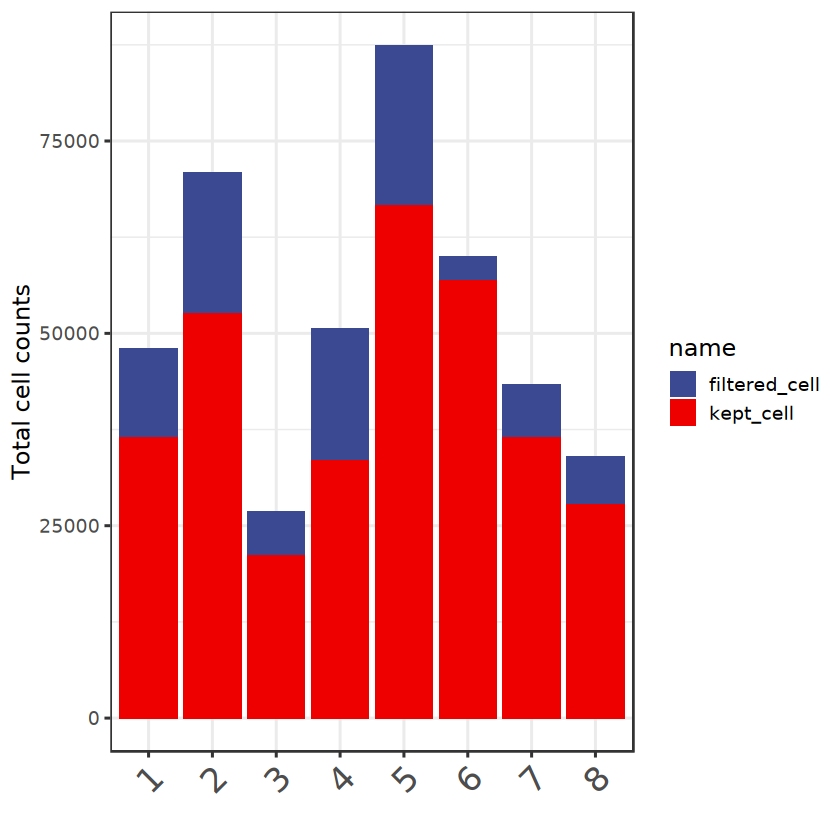

In [49]:
p10

In [50]:
baysor.cnt = orig.baysor@meta.data %>% group_by(sample) %>% summarise(n=sum(nCount_RNA))

In [51]:
baysor.cnt

sample,n
<fct>,<dbl>
output-XETG00392__0045655__BS21-N65682A2__20241025__201009_orig_seg.h5ad,7914526
output-XETG00392__0045655__BS22-T41795A1__20241025__201009_orig_seg.h5ad,4899956
output-XETG00392__0045655__BS24-M35359A1__20241025__201009_orig_seg.h5ad,11668783
output-XETG00392__0045655__BS24-R31519A2__20241025__201009_orig_seg.h5ad,15315788
output-XETG00150__0018462__BS22_12012A1__20240803__183643_orig_seg.h5ad,13244920
output-XETG00150__0018462__BS23_49001A1__20240803__183643_orig_seg.h5ad,12197292
output-XETG00150__0018462__BS23_52206A2__20240803__183643_orig_seg.h5ad,20025472
output-XETG00150__0018462__BS2_61615A1__20240803__183643_orig_seg.h5ad,6951452


In [52]:
baysor.filtered.cnt = lennard.subtype@meta.data %>% group_by(sample) %>% summarise(n=sum(nCount_RNA))

In [53]:
baysor.filtered.cnt

sample,n
<chr>,<dbl>
output-XETG00150__0018462__BS22_12012A1__20240803__183643_orig_seg.h5ad,12595649
output-XETG00150__0018462__BS23_49001A1__20240803__183643_orig_seg.h5ad,11465069
output-XETG00150__0018462__BS23_52206A2__20240803__183643_orig_seg.h5ad,19873495
output-XETG00150__0018462__BS2_61615A1__20240803__183643_orig_seg.h5ad,6381756
output-XETG00392__0045655__BS21-N65682A2__20241025__201009_orig_seg.h5ad,7489766
output-XETG00392__0045655__BS22-T41795A1__20241025__201009_orig_seg.h5ad,4678675
output-XETG00392__0045655__BS24-M35359A1__20241025__201009_orig_seg.h5ad,11429536
output-XETG00392__0045655__BS24-R31519A2__20241025__201009_orig_seg.h5ad,15046206


In [54]:
(baysor.filtered.cnt %>% mutate(sample=gsub("_orig_seg.h5ad", "", sample))) 

sample,n
<chr>,<dbl>
output-XETG00150__0018462__BS22_12012A1__20240803__183643,12595649
output-XETG00150__0018462__BS23_49001A1__20240803__183643,11465069
output-XETG00150__0018462__BS23_52206A2__20240803__183643,19873495
output-XETG00150__0018462__BS2_61615A1__20240803__183643,6381756
output-XETG00392__0045655__BS21-N65682A2__20241025__201009,7489766
output-XETG00392__0045655__BS22-T41795A1__20241025__201009,4678675
output-XETG00392__0045655__BS24-M35359A1__20241025__201009,11429536
output-XETG00392__0045655__BS24-R31519A2__20241025__201009,15046206


In [55]:
joint.cnt <- (baysor.filtered.cnt %>% mutate(sample=gsub("_orig_seg.h5ad", "", sample))) %>% 
    left_join(baysor.cnt %>% mutate(sample=gsub("_orig_seg.h5ad", "", sample)), by="sample") %>% 
    rename(kept_molecule = `n.x`, all_cells = `n.y`) %>% mutate(filtered_molecule=all_cells-kept_molecule) %>% 
    select(sample, kept_molecule, filtered_molecule) %>% 
    pivot_longer(cols=c(kept_molecule, filtered_molecule))
joint.cnt = joint.cnt %>% mutate(sample=str_extract(sample, "_(BS\\d*[_-].*A\\d)_", group = 1))

In [56]:
joint.cnt

sample,name,value
<chr>,<chr>,<dbl>
BS22_12012A1,kept_molecule,12595649
BS22_12012A1,filtered_molecule,649271
BS23_49001A1,kept_molecule,11465069
BS23_49001A1,filtered_molecule,732223
BS23_52206A2,kept_molecule,19873495
BS23_52206A2,filtered_molecule,151977
BS2_61615A1,kept_molecule,6381756
BS2_61615A1,filtered_molecule,569696
BS21-N65682A2,kept_molecule,7489766


In [57]:
joint.cnt = joint.cnt %>% mutate(patient2=sample_translator[match(sample, names(sample_translator))])
p20=joint.cnt %>% ggplot() + geom_bar(aes(x=patient2, y=value, fill=name), stat='identity') + ggsci::scale_fill_aaas() + 
    ylab("Total transcripts counts") + xlab("")+ theme_bw(base_size = 14) +
 theme(
   axis.text.x = element_text(angle = 45,size=20, hjust = 1)
 )

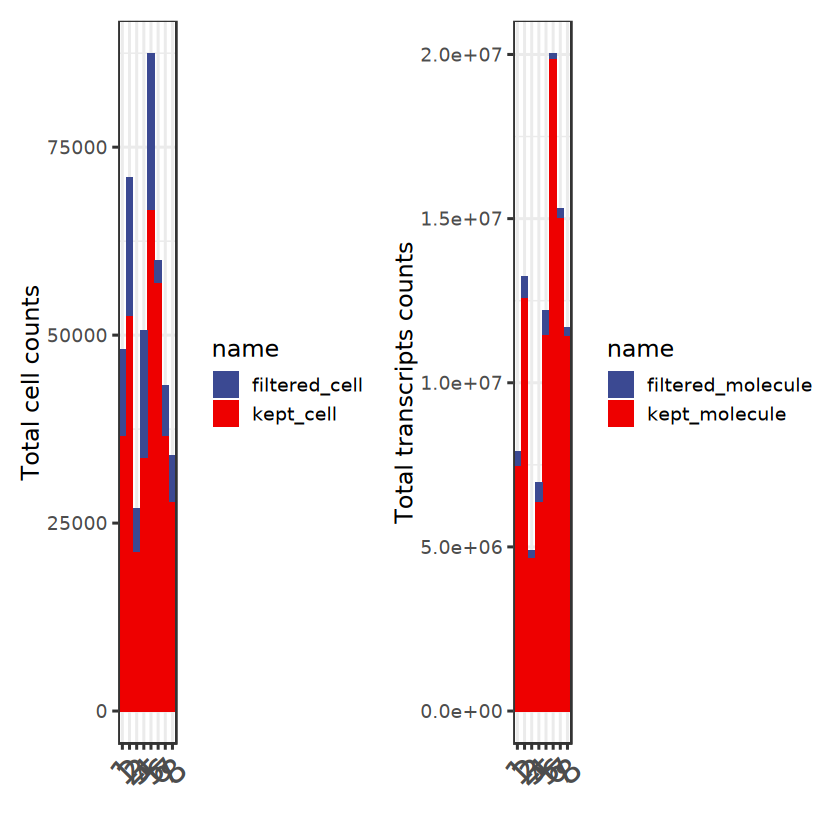

In [58]:
p10|p20

# Fig.1b QC of xenium based on SOPA

In [121]:
head(obj.merge@meta.data)

,uniq_id,orig.ident,nCount_RNA,nFeature_RNA,region,cell_id,slide,area,sample,scDblFinder.class,⋯,rowname,lennard_subtype,lennard_label,sample_id,case_ctrl,case_ctrl_num,cell_label,sample_id_de,Tcell_label,condition
,<chr>,<chr>,<dbl>,<int>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,⋯,<chr>,<chr>,<fct>,<chr>,<chr>,<dbl>,<chr>,<chr>,<lgl>,<fct>
3,3_output-XETG00392__0045655__BS21-N65682A2__20241025__201009_orig_seg.h5ad,output-XETG00392__0045655__BS21-N65682A2__20241025__201009_orig_seg.h5ad,107,97,baysor_boundaries,aaaaaaac-1,morphology_focus,47.75371,output-XETG00392__0045655__BS21-N65682A2__20241025__201009_orig_seg.h5ad,singlet,⋯,3,Proinflammatory Myeloid Cells,Inflammatory Myeloid,BS21-N65682A2,Case,2,Inflammatory Myeloid,1,FALSE,Case
4,4_output-XETG00392__0045655__BS21-N65682A2__20241025__201009_orig_seg.h5ad,output-XETG00392__0045655__BS21-N65682A2__20241025__201009_orig_seg.h5ad,87,73,baysor_boundaries,aaaaaaad-1,morphology_focus,114.91816,output-XETG00392__0045655__BS21-N65682A2__20241025__201009_orig_seg.h5ad,singlet,⋯,4,NA,Proximal Tubule,BS21-N65682A2,Case,2,Proximal Tubule,1,FALSE,Case
5,5_output-XETG00392__0045655__BS21-N65682A2__20241025__201009_orig_seg.h5ad,output-XETG00392__0045655__BS21-N65682A2__20241025__201009_orig_seg.h5ad,133,114,baysor_boundaries,aaaaaaae-1,morphology_focus,45.60825,output-XETG00392__0045655__BS21-N65682A2__20241025__201009_orig_seg.h5ad,singlet,⋯,5,NA,Proximal Tubule,BS21-N65682A2,Case,2,Proximal Tubule,1,FALSE,Case
6,6_output-XETG00392__0045655__BS21-N65682A2__20241025__201009_orig_seg.h5ad,output-XETG00392__0045655__BS21-N65682A2__20241025__201009_orig_seg.h5ad,172,154,baysor_boundaries,aaaaaaaf-1,morphology_focus,78.27605,output-XETG00392__0045655__BS21-N65682A2__20241025__201009_orig_seg.h5ad,singlet,⋯,6,NA,Endothelial Cell,BS21-N65682A2,Case,2,Endothelial Cell,1,FALSE,Case
7,7_output-XETG00392__0045655__BS21-N65682A2__20241025__201009_orig_seg.h5ad,output-XETG00392__0045655__BS21-N65682A2__20241025__201009_orig_seg.h5ad,372,289,baysor_boundaries,aaaaaaag-1,morphology_focus,113.95260,output-XETG00392__0045655__BS21-N65682A2__20241025__201009_orig_seg.h5ad,doublet,⋯,7,NA,Inflammatory Myeloid,BS21-N65682A2,Case,2,Inflammatory Myeloid,1,FALSE,Case
9,9_output-XETG00392__0045655__BS21-N65682A2__20241025__201009_orig_seg.h5ad,output-XETG00392__0045655__BS21-N65682A2__20241025__201009_orig_seg.h5ad,65,59,baysor_boundaries,aaaaaaai-1,morphology_focus,57.63673,output-XETG00392__0045655__BS21-N65682A2__20241025__201009_orig_seg.h5ad,singlet,⋯,9,T Cell Lineage,Immune Cell (LowQ),BS21-N65682A2,Case,2,Immune Cell (LowQ),1,FALSE,Case


In [132]:
head(obj.merge@meta.data %>% count(sample_id, lennard_label, condition) %>% group_by(condition) %>% 
     mutate(ratio=n/sum(n)) %>% ungroup() %>% select(lennard_label, condition, ratio) )

lennard_label,condition,ratio
<fct>,<fct>,<dbl>
T Cell,Case,0.017880751
Regulatory T Cell,Case,0.003657677
Proliferating T Cell,Case,0.001178830
Immune Cell (LowQ),Case,0.009722589
B Cell,Case,0.006918738
Plasma Cell,Case,0.002440287


In [134]:
obj.merge@meta.data %>% count(sample_id, lennard_label, condition) %>% group_by(condition) %>% 
     mutate(ratio=n/sum(n)) %>% ungroup() %>% select(lennard_label, condition, ratio) %>% 
     pivot_wider(names_from=c("condition"), values_from="ratio", values_fn=mean) %>% 
     mutate(ratio=Case/Control)    

lennard_label,Case,Control,ratio
<fct>,<dbl>,<dbl>,<dbl>
T Cell,0.0300243478,0.0053363615,5.6263706
Regulatory T Cell,0.0038876586,0.0005089354,7.6388060
Proliferating T Cell,0.0030186850,0.0003779716,7.9865402
Immune Cell (LowQ),0.0174676097,0.0035061835,4.9819440
B Cell,0.0034125463,0.0004509134,7.5680741
Plasma Cell,0.0037334193,0.0001375949,27.1334117
Tissue Myeloid,0.0201833245,0.0065316137,3.0900977
Monocyte,0.0011554182,0.0003531050,3.2721661
Inflammatory Myeloid,0.0244744844,0.0067156261,3.6444084


In [135]:
obj.merge@meta.data %>% count(sample_id, lennard_label, condition) %>% group_by(condition) %>% 
     mutate(ratio=n/sum(n)) %>% ungroup() %>% select(lennard_label, condition, ratio) %>% 
     pivot_wider(names_from=c("condition"), values_from="ratio", values_fn=mean) %>% 
     mutate(ratio=Control/Case) 

lennard_label,Case,Control,ratio
<fct>,<dbl>,<dbl>,<dbl>
T Cell,0.0300243478,0.0053363615,0.17773447
Regulatory T Cell,0.0038876586,0.0005089354,0.13091051
Proliferating T Cell,0.0030186850,0.0003779716,0.12521066
Immune Cell (LowQ),0.0174676097,0.0035061835,0.20072486
B Cell,0.0034125463,0.0004509134,0.13213401
Plasma Cell,0.0037334193,0.0001375949,0.03685493
Tissue Myeloid,0.0201833245,0.0065316137,0.32361436
Monocyte,0.0011554182,0.0003531050,0.30560796
Inflammatory Myeloid,0.0244744844,0.0067156261,0.27439296


In [125]:
obj.merge@meta.data %>% count(sample_id, lennard_label, condition) %>% group_by(condition) # %>%
    summarise(ratio=n/sum(n))

sample_id,lennard_label,condition,n
<chr>,<fct>,<fct>,<int>
BS21-N65682A2,T Cell,Case,3246
BS21-N65682A2,Regulatory T Cell,Case,664
BS21-N65682A2,Proliferating T Cell,Case,214
BS21-N65682A2,Immune Cell (LowQ),Case,1765
BS21-N65682A2,B Cell,Case,1256
BS21-N65682A2,Plasma Cell,Case,443
BS21-N65682A2,Tissue Myeloid,Case,2464
BS21-N65682A2,Monocyte,Case,173
BS21-N65682A2,Inflammatory Myeloid,Case,3115


ERROR: Error in sum(n): invalid 'type' (closure) of argument


In [60]:
names(celltype_colors)

[1] "T Cell"                   "Regulatory T Cell"       
 [3] "Proliferating T Cell"     "Immune Cell (LowQ)"      
 [5] "B Cell"                   "Plasma Cell"             
 [7] "Tissue Myeloid"           "Monocyte"                
 [9] "Inflammatory Myeloid"     "cDC1"                    
[11] "pDC"                      "Mast Cell"               
[13] "Endothelial Cell"         "Stromal Cell"            
[15] "Podocyte"                 "Parietal Cell"           
[17] "Proximal Tubule"          "Loop of Henle"           
[19] "Distal Convoluted Tubule" "Collecting Duct"

In [61]:
obj.merge@meta.data = obj.merge@meta.data %>% mutate(lennard_label = factor(lennard_label, levels=names(celltype_colors)))

In [62]:
obj.merge$sample_id[1:10]

3               4               5               6               7 
"BS21-N65682A2" "BS21-N65682A2" "BS21-N65682A2" "BS21-N65682A2" "BS21-N65682A2" 
              9              10              11              12              15 
"BS21-N65682A2" "BS21-N65682A2" "BS21-N65682A2" "BS21-N65682A2" "BS21-N65682A2"

In [63]:
obj.merge@meta.data$sample_id_de <- sample_translator[obj.merge$sample_id]

In [64]:
fig.size(8, 12)
plot.df.prop <- obj.merge@meta.data %>% 
  count(sample_id_de, lennard_label) %>% 
  group_by(sample_id_de) %>% 
  mutate(prop = n / sum(n)) %>% 
  ungroup()

p.new <- ggplot(plot.df.prop, aes(x = sample_id_de, y = prop, fill = lennard_label)) +
  geom_bar(stat = "identity", width = 0.8) +
  theme_bw(base_size = 14) +
  labs(
    x = "Sample",
    y = "Proportion",
    fill = "Cell type"
  ) + xlab("")+
  theme(
    axis.text.x = element_text(angle = 45,size=20, hjust = 1)
  )+ scale_fill_manual(values = celltype_colors)

In [65]:
getwd()

[1] "/n/data1/bwh/medicine/korsunsky/lab/alvin/ICI/phaseP_JITC"

In [66]:
#p3a = VlnPlot_scCustom(subset(obj.merge), features=c("CD3E", "CD4", "CD8A", "FOXP3"), 
#                       group.by="lennard_label", pt.size = 0, num_columns=2) + NoLegend() + scale_fill_manual(values=celltype_colors)
p4b = VlnPlot_scCustom(obj.merge, features=c("nFeature_RNA"), 
                       group.by="lennard_label", pt.size = 0) + NoLegend() + scale_fill_manual(values=celltype_colors)
p4e = VlnPlot_scCustom(obj.merge, features=c("nCount_RNA"), 
                       group.by="lennard_label", pt.size = 0) + NoLegend() + scale_fill_manual(values=celltype_colors)

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


In [67]:
p4c = VlnPlot_scCustom(obj.merge, features=c("nFeature_RNA", "nCount_RNA"), 
                       group.by="sample_id_de", pt.size = 0) + NoLegend() #+ scale_fill_manual(values=celltype_colors)

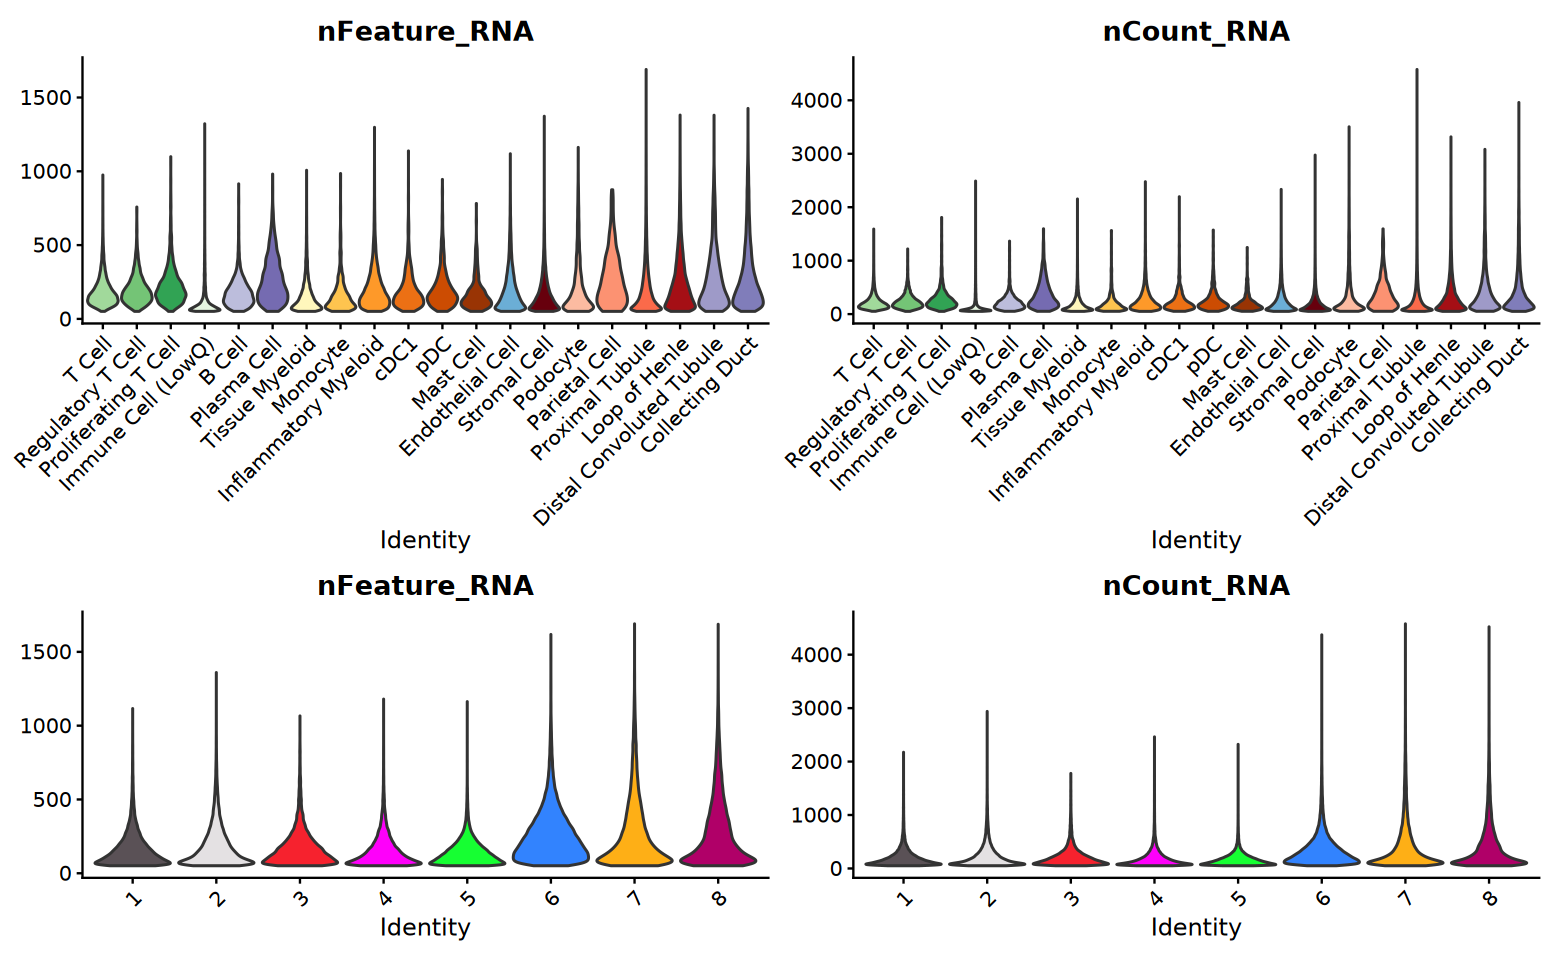

In [68]:
fig.size(8,13)
(p4b | p4e) / p4c

In [69]:
names(celltype_colors)

[1] "T Cell"                   "Regulatory T Cell"       
 [3] "Proliferating T Cell"     "Immune Cell (LowQ)"      
 [5] "B Cell"                   "Plasma Cell"             
 [7] "Tissue Myeloid"           "Monocyte"                
 [9] "Inflammatory Myeloid"     "cDC1"                    
[11] "pDC"                      "Mast Cell"               
[13] "Endothelial Cell"         "Stromal Cell"            
[15] "Podocyte"                 "Parietal Cell"           
[17] "Proximal Tubule"          "Loop of Henle"           
[19] "Distal Convoluted Tubule" "Collecting Duct"

In [70]:
obj.merge@meta.data$Tcell_label = obj.merge@meta.data$lennard_label %in% c("T Cell", "Regulatory T Cell", "Proliferating T Cell")

In [71]:
p3Ta = VlnPlot_scCustom(subset(obj.merge, subset=Tcell_label), features=c("CD3E"), 
                       group.by="lennard_label", pt.size = 0, num_columns=1) + NoLegend() + scale_fill_manual(values=celltype_colors)
p3Tb = VlnPlot_scCustom(subset(obj.merge, subset=Tcell_label), features=c("CD4"), 
                       group.by="lennard_label", pt.size = 0, num_columns=1) + NoLegend() + scale_fill_manual(values=celltype_colors)
p3Tc = VlnPlot_scCustom(subset(obj.merge, subset=Tcell_label), features=c("CD8A"), 
                       group.by="lennard_label", pt.size = 0, num_columns=1) + NoLegend() + scale_fill_manual(values=celltype_colors)
p3Td = VlnPlot_scCustom(subset(obj.merge, subset=Tcell_label), features=c("FOXP3"), 
                       group.by="lennard_label", pt.size = 0, num_columns=1) + NoLegend() + scale_fill_manual(values=celltype_colors)

# p4T = VlnPlot_scCustom(subset(obj.merge, subset=Tcell_label), features=c("nFeature_RNA", "nCount_RNA"), 
#                        group.by="lennard_label", pt.size = 0) + NoLegend() + scale_fill_manual(values=celltype_colors)

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


In [72]:
library(patchwork)

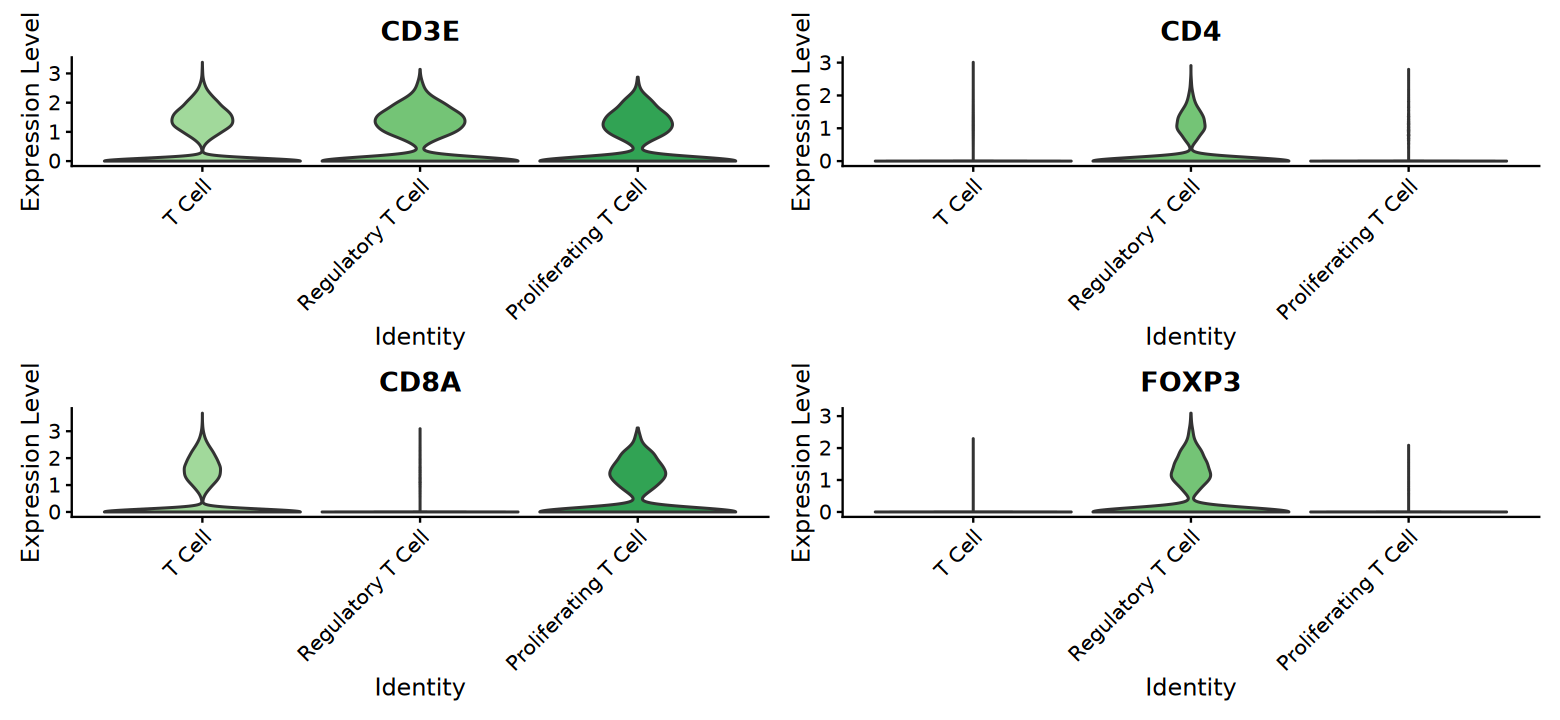

In [73]:
fig.size(6,13)
p3T = p3Ta + p3Tb + p3Tc + p3Td + plot_layout(ncol=2)
p3T

# Fig.1c

In [74]:
# orig.merge@meta.data  = orig.merge@meta.data %>% mutate(cell_label=case_when(
#     cell_label %in% c("Basophil") ~ "Mast", 
#     cell_label %in% c("Interstitial") ~ "Stroma",  
#     .default = cell_label 
# )
#                                                      )

In [75]:
p11=DimPlot_scCustom(subset(orig.merge, subset = tech=='sc'), raster = TRUE, label=F, repel=T, label.size=6,
    raster.dpi = c(500, 500), group.by="cell_type", seed=99) +
    scale_x_continuous(breaks = NULL) +
    scale_y_continuous(breaks = NULL) + ggtitle("KPMP scRNA-seq")+xlab("")+ylab("") +guides(fill = guide_legend(ncol = 1)) #+
#    scale_color_manual(values=celltype_colors)

p12=DimPlot_scCustom(subset(orig.merge, subset = tech=='xenium'), raster = TRUE,        # enable rasterization
   raster.dpi = c(500, 500),  group.by="cell_type", seed=99) +ggplot2::theme(legend.position = "none") + 
   ggtitle("Xenium 8 patients")+scale_x_continuous(breaks = NULL)+ scale_y_continuous(breaks = NULL)+xlab("")+ylab("") #+
#   scale_color_manual(values=celltype_colors)


In [76]:
head(sample_mat)

,B Cell,Collecting Duct,Distal Convoluted Tubule,Endothelial Cell,Immune Cell (LowQ),Inflammatory Myeloid,Loop of Henle,Mast Cell,Monocyte,Parietal Cell,Plasma Cell,Podocyte,Proliferating T Cell,Proximal Tubule,Regulatory T Cell,Stromal Cell,T Cell,Tissue Myeloid,cDC1,pDC
BS22_12012A1,0.0029817864,0.09330902,0.014548079,0.09479042,0.01462405,0.03441399,0.08966251,0.001367443,0.002165119,0.0019941884,0.0011015517,0.0189732779,0.0030577555,0.3637210,0.0038934154,0.19119518,0.02772871,0.03686400,0.001918219,0.0016903120
BS23_49001A1,0.0115354077,0.07090530,0.008479274,0.04067355,0.09782625,0.09721203,0.07782655,0.003460622,0.004868841,0.0014981049,0.0037602433,0.0057976660,0.0227412323,0.1839074,0.0179772588,0.06200656,0.17345059,0.09497985,0.011700199,0.0093931177
BS23_52206A2,0.0033898305,0.02882234,0.006885044,0.10069377,0.05861070,0.10749100,0.12422938,0.001334856,0.004478792,0.0010889611,0.0346359884,0.0053745499,0.0044787916,0.1589708,0.0129094582,0.16724335,0.09342232,0.07808905,0.003811364,0.0040396944
BS2_61615A1,0.0008613009,0.11196911,0.021740422,0.09774280,0.01517672,0.02631423,0.10763291,0.001306801,0.001128601,0.0018414018,0.0004752005,0.0136620137,0.0009207009,0.3819127,0.0005049005,0.17793288,0.01378081,0.02307692,0.001633502,0.0003861004
BS21-N65682A2,0.0343178775,0.05511080,0.013524960,0.06505642,0.04822536,0.08511162,0.05429110,0.005191399,0.004726905,0.0015027733,0.0121041559,0.0138528375,0.0058471543,0.2633405,0.0181425722,0.14948496,0.08869095,0.06732424,0.006748818,0.0074045739
BS22-T41795A1,0.0121876618,0.05905604,0.012422945,0.10738318,0.04950355,0.09637194,0.14615783,0.003246906,0.004046868,0.0006117359,0.0021175474,0.0007058491,0.0096466049,0.1445579,0.0105406804,0.18610889,0.07806691,0.06616159,0.006493812,0.0046115477


In [77]:
dim(sample_mat)

[1]  8 20

In [78]:
my_sample_col

,sample,group,patient_id,group_simple,patient
,<chr>,<chr>,<chr>,<chr>,<int>
BS21-N65682A2,Case,ICI-AIN,AIN_1,AIN,1
BS22-T41795A1,Case,ICI-AIN,AIN_2,AIN,2
BS23_49001A1,Case,ICI-AIN,AIN_3,AIN,3
BS23_52206A2,Case,ICI-AIN,AIN_4,AIN,4
BS22_12012A1,Control,ICI-ATN,ATN_1,ATN,1
BS2_61615A1,Control,ICI-ATN,ATN_2,ATN,2
BS24-R31519A2,Control,ICI-ATN,ATN_3,ATN,3
BS24-M35359A1,Control,ICI-ATN,ATN_4,ATN,4


In [79]:
colnames(sample_mat)

[1] "B Cell"                   "Collecting Duct"         
 [3] "Distal Convoluted Tubule" "Endothelial Cell"        
 [5] "Immune Cell (LowQ)"       "Inflammatory Myeloid"    
 [7] "Loop of Henle"            "Mast Cell"               
 [9] "Monocyte"                 "Parietal Cell"           
[11] "Plasma Cell"              "Podocyte"                
[13] "Proliferating T Cell"     "Proximal Tubule"         
[15] "Regulatory T Cell"        "Stromal Cell"            
[17] "T Cell"                   "Tissue Myeloid"          
[19] "cDC1"                     "pDC"

In [80]:
sample_mat = sample_mat[rownames(my_sample_col),]
rownames(sample_mat) = my_sample_col$patient_id

In [81]:
sample_mat <- scale(sample_mat)

In [82]:
head(sample_mat)

,B Cell,Collecting Duct,Distal Convoluted Tubule,Endothelial Cell,Immune Cell (LowQ),Inflammatory Myeloid,Loop of Henle,Mast Cell,Monocyte,Parietal Cell,Plasma Cell,Podocyte,Proliferating T Cell,Proximal Tubule,Regulatory T Cell,Stromal Cell,T Cell,Tissue Myeloid,cDC1,pDC
AIN_1,2.2664994,-0.7125432,-0.3747272,-0.9221048,0.3043159,0.6157396,-1.22199858,1.9603866,1.0078463,-0.1859111,0.4438369,-0.08788749,-0.01822159,-0.2285116,1.3070361,-0.03722059,0.4340841,0.5569417,0.6526863,1.1166609
AIN_2,0.3207481,-0.6182414,-0.5102889,0.6510032,0.3461143,0.9081514,1.71952898,0.6004512,0.6266266,-1.8047344,-0.3937980,-1.24250149,0.49141221,-1.2448680,0.2921215,0.84203255,0.2415075,0.5177954,0.5860780,0.3090037
AIN_3,0.2634001,-0.3350129,-0.9954101,-1.8283140,1.9263257,0.9299672,-0.46840506,0.7499196,1.0874137,-0.1943926,-0.2560156,-0.79532052,2.24784110,-0.9081768,1.2849654,-2.13736810,1.9704800,1.4881026,1.9460012,1.6916865
AIN_4,-0.4527821,-1.3409062,-1.1915204,0.4023860,0.6439290,1.1968950,1.01739097,-0.7367950,0.8687571,-0.9377189,2.3337129,-0.83248003,-0.20176493,-1.1215453,0.6083726,0.38911594,0.5198474,0.9193914,-0.1145851,0.1436414
ATN_1,-0.4886585,0.2004947,-0.2488706,0.1829831,-0.7944882,-0.7007935,-0.08942349,-0.7140037,-0.4282576,0.7068844,-0.4790155,0.36180729,-0.39237355,0.6303876,-0.5953427,0.96414235,-0.6709481,-0.4686511,-0.6090799,-0.5357276
ATN_2,-0.6750976,0.6465198,0.6358781,0.2927106,-0.7764153,-0.9111310,0.48597992,-0.7564155,-1.0093159,0.4293041,-0.5315512,-0.10464630,-0.67902427,0.7860439,-1.0477372,0.64574604,-0.9237748,-0.9328602,-0.6834490,-0.9128655


In [83]:
my_sample_col = my_sample_col %>% rownames_to_column()
my_sample_col = my_sample_col %>% column_to_rownames(var='patient_id')

In [84]:
head(my_sample_col)

,rowname,sample,group,group_simple,patient
,<chr>,<chr>,<chr>,<chr>,<int>
AIN_1,BS21-N65682A2,Case,ICI-AIN,AIN,1
AIN_2,BS22-T41795A1,Case,ICI-AIN,AIN,2
AIN_3,BS23_49001A1,Case,ICI-AIN,AIN,3
AIN_4,BS23_52206A2,Case,ICI-AIN,AIN,4
ATN_1,BS22_12012A1,Control,ICI-ATN,ATN,1
ATN_2,BS2_61615A1,Control,ICI-ATN,ATN,2


In [85]:
length(colnames(sample_mat))

[1] 20

In [86]:
length(names(celltype_colors))

[1] 20

In [87]:
col_fun <- colorRamp2(c(-1, 0, 1), c("blue", "white", "red"))
ht_opt("heatmap_row_names_gp" = gpar(fontsize = 15))
ha1 = rowAnnotation(samples = my_sample_col$group,
                    col=list(samples=c('ICI-AIN'='gray', 'ICI-ATN'='black')),
                    annotation_name_gp = gpar(fontsize = 15),
                    annotation_legend_param = list(
                    samples = list(title_gp = gpar(fontsize = 15), labels_gp = gpar(fontsize = 5), direction = "horizontal")))

#colnames(sample_mat)[colnames(sample_mat)=='Immune Cell'] = 'Immune (LowQ)'
#colnames(sample_mat) = gsub(" Cell", "", colnames(sample_mat))


In [88]:
setdiff(colnames(sample_mat), names(celltype_colors))

character(0)

In [89]:
colnames(sample_mat)

[1] "B Cell"                   "Collecting Duct"         
 [3] "Distal Convoluted Tubule" "Endothelial Cell"        
 [5] "Immune Cell (LowQ)"       "Inflammatory Myeloid"    
 [7] "Loop of Henle"            "Mast Cell"               
 [9] "Monocyte"                 "Parietal Cell"           
[11] "Plasma Cell"              "Podocyte"                
[13] "Proliferating T Cell"     "Proximal Tubule"         
[15] "Regulatory T Cell"        "Stromal Cell"            
[17] "T Cell"                   "Tissue Myeloid"          
[19] "cDC1"                     "pDC"

In [90]:
names(celltype_colors)

[1] "T Cell"                   "Regulatory T Cell"       
 [3] "Proliferating T Cell"     "Immune Cell (LowQ)"      
 [5] "B Cell"                   "Plasma Cell"             
 [7] "Tissue Myeloid"           "Monocyte"                
 [9] "Inflammatory Myeloid"     "cDC1"                    
[11] "pDC"                      "Mast Cell"               
[13] "Endothelial Cell"         "Stromal Cell"            
[15] "Podocyte"                 "Parietal Cell"           
[17] "Proximal Tubule"          "Loop of Henle"           
[19] "Distal Convoluted Tubule" "Collecting Duct"

In [91]:
sample_mat = sample_mat[, names(celltype_colors)]

In [92]:
sample_mat

,T Cell,Regulatory T Cell,Proliferating T Cell,Immune Cell (LowQ),B Cell,Plasma Cell,Tissue Myeloid,Monocyte,Inflammatory Myeloid,cDC1,pDC,Mast Cell,Endothelial Cell,Stromal Cell,Podocyte,Parietal Cell,Proximal Tubule,Loop of Henle,Distal Convoluted Tubule,Collecting Duct
AIN_1,0.4340841,1.3070361,-0.01822159,0.3043159,2.2664994,0.4438369,0.5569417,1.0078463,0.6157396,0.6526863,1.1166609,1.9603866,-0.9221048,-0.03722059,-0.08788749,-0.1859111,-0.2285116,-1.22199858,-0.3747272,-0.7125432
AIN_2,0.2415075,0.2921215,0.49141221,0.3461143,0.3207481,-0.3937980,0.5177954,0.6266266,0.9081514,0.5860780,0.3090037,0.6004512,0.6510032,0.84203255,-1.24250149,-1.8047344,-1.2448680,1.71952898,-0.5102889,-0.6182414
AIN_3,1.9704800,1.2849654,2.24784110,1.9263257,0.2634001,-0.2560156,1.4881026,1.0874137,0.9299672,1.9460012,1.6916865,0.7499196,-1.8283140,-2.13736810,-0.79532052,-0.1943926,-0.9081768,-0.46840506,-0.9954101,-0.3350129
AIN_4,0.5198474,0.6083726,-0.20176493,0.6439290,-0.4527821,2.3337129,0.9193914,0.8687571,1.1968950,-0.1145851,0.1436414,-0.7367950,0.4023860,0.38911594,-0.83248003,-0.9377189,-1.1215453,1.01739097,-1.1915204,-1.3409062
ATN_1,-0.6709481,-0.5953427,-0.39237355,-0.7944882,-0.4886585,-0.4790155,-0.4686511,-0.4282576,-0.7007935,-0.6090799,-0.5357276,-0.7140037,0.1829831,0.96414235,0.36180729,0.7068844,0.6303876,-0.08942349,-0.2488706,0.2004947
ATN_2,-0.9237748,-1.0477372,-0.67902427,-0.7764153,-0.6750976,-0.5315512,-0.9328602,-1.0093159,-0.9111310,-0.6834490,-0.9128655,-0.7564155,0.2927106,0.64574604,-0.10464630,0.4293041,0.7860439,0.48597992,0.6358781,0.6465198
ATN_3,-0.9621662,-1.0312744,-0.75123006,-1.0083303,-0.7388183,-0.5668272,-1.2721085,-1.3357636,-1.2419532,-0.9674372,-0.9850228,-0.5624229,1.4341599,-0.30865593,1.75872694,1.2521767,0.7952549,-0.65065147,1.0996773,1.9193331
ATN_4,-0.6090300,-0.8181413,-0.69663891,-0.6414510,-0.4952910,-0.5503423,-0.8086113,-0.8173066,-0.7968754,-0.8102143,-0.8273766,-0.5411203,-0.2128240,-0.35779226,0.94230159,0.7343917,1.2914153,-0.79242128,1.5852618,0.2403560


In [93]:
# # Desired cell size
# cell_width <- unit(2.5, "mm")   # width per column
# cell_height <- unit(3.5, "mm")   # height per row
# # Main heatmap
# ht2 <- Heatmap(
#   t(sample_mat),
#   name = "Expression",
#   col = col_fun,
# #  width = cell_width * ncol(sample_mat),
# #  height = cell_height * nrow(sample_mat),
#   column_names_gp = gpar(fontsize = 15),
#   heatmap_legend_param = list(
#     title_gp = gpar(fontsize = 15),
#     labels_gp = gpar(fontsize = 15),
#     direction = "horizontal"
#   ),cluster_columns = FALSE,
#   column_names_side = "top",
#   right_annotation = ha1)
# ht_plot <- wrap_elements(full=grid.grabExpr(draw(ht2,
#                               merge_legend = TRUE, heatmap_legend_side = "bottom",
#                               annotation_legend_list = NULL)))

In [94]:
# ht_plot

# Supp Fig. 1e

In [95]:
table(obj.merge$sample_id)


  BS2_61615A1 BS21-N65682A2  BS22_12012A1 BS22-T41795A1  BS23_49001A1 
        33670         36599         52653         21251         66751 
 BS23_52206A2 BS24-M35359A1 BS24-R31519A2 
        56935         27870         36612 

In [96]:
obj.merge@meta.data$condition = factor(str_trim(orig.merge.xen@meta.data$case_ctrl), levels=c("Control", "Case"))

In [97]:
# head(obj.merge@meta.data[, c("sample_id", "cell_label", "case_ctrl")])

In [98]:
library(sccomp)

res = obj.merge %>% sccomp_estimate(,
      formula_composition = ~ condition,
      sample = "sample_id", cell_group = "lennard_label",
      cores = 1, verbose=T
    )


Loading required package: instantiate

sccomp says: count column is an integer. The sum-constrained beta binomial model will be used

sccomp says: estimation

sccomp says: the composition design matrix has columns: (Intercept), conditionCase

sccomp says: the variability design matrix has columns: (Intercept)

Loading model from cache...



Path [1] :Initial log joint density = -1030827.795692 
Path [1] : Iter      log prob        ||dx||      ||grad||     alpha      alpha0      # evals       ELBO    Best ELBO        Notes  
            100      -1.030e+06      7.504e-02   2.752e+03    8.817e-02  8.817e-02      8389 -1.263e+03 -2.030e+03                   
Path [1] :Best Iter: [32] ELBO (-1262.575635) evaluations: (8389) 
Path [2] :Initial log joint density = -1031476.490057 
Path [2] : Iter      log prob        ||dx||      ||grad||     alpha      alpha0      # evals       ELBO    Best ELBO        Notes  
            100      -1.030e+06      6.608e-02   6.492e+03    7.070e-02  1.385e-01      8732 -1.266e+03 -1.278e+04                   
Path [2] :Best Iter: [25] ELBO (-1266.113138) evaluations: (8732) 
Path [3] :Initial log joint density = -1030580.651200 
Path [3] : Iter      log prob        ||dx||      ||grad||     alpha      alpha0      # evals       ELBO    Best ELBO        Notes  
            100      -1.030e+06      

sccomp says: to do hypothesis testing run `sccomp_test()`,
  the `test_composition_above_logit_fold_change` = 0.1 equates to a change of ~10%, and
  0.7 equates to ~100% increase, if the baseline is ~0.1 proportion.
  Use `sccomp_proportional_fold_change` to convert c_effect (linear) to proportion difference (non-linear).

sccomp says: auto-cleanup removed 1 draw files from 'sccomp_draws_files'



In [99]:
res = res |>  sccomp_test()

In [100]:
pn = (res %>% plot_1D_intervals())+get_theme(size=16)

In [101]:
p2e=FeaturePlot_scCustom(subset(orig.merge, subset = tech=='xenium'), 
                         raster = TRUE, features=markers[seq(1, length(markers), 2)],
    raster.dpi = c(150, 150)) #+scale_x_continuous(breaks = NULL)+ scale_y_continuous(breaks = NULL)+xlab("")+ylab("") 


NOTE: FeaturePlot_scCustom uses a specified `na_cutoff` when plotting to
color cells with no expression as background color separate from color scale.
Please ensure `na_cutoff` value is appropriate for feature being plotted.
Default setting is appropriate for use when plotting from 'RNA' assay.
When `na_cutoff` not appropriate (e.g., module scores) set to NULL to
plot all cells in gradient color palette.

-----This message will be shown once per session.-----


In [102]:
suppfig1e = p2e
#suppfig1e

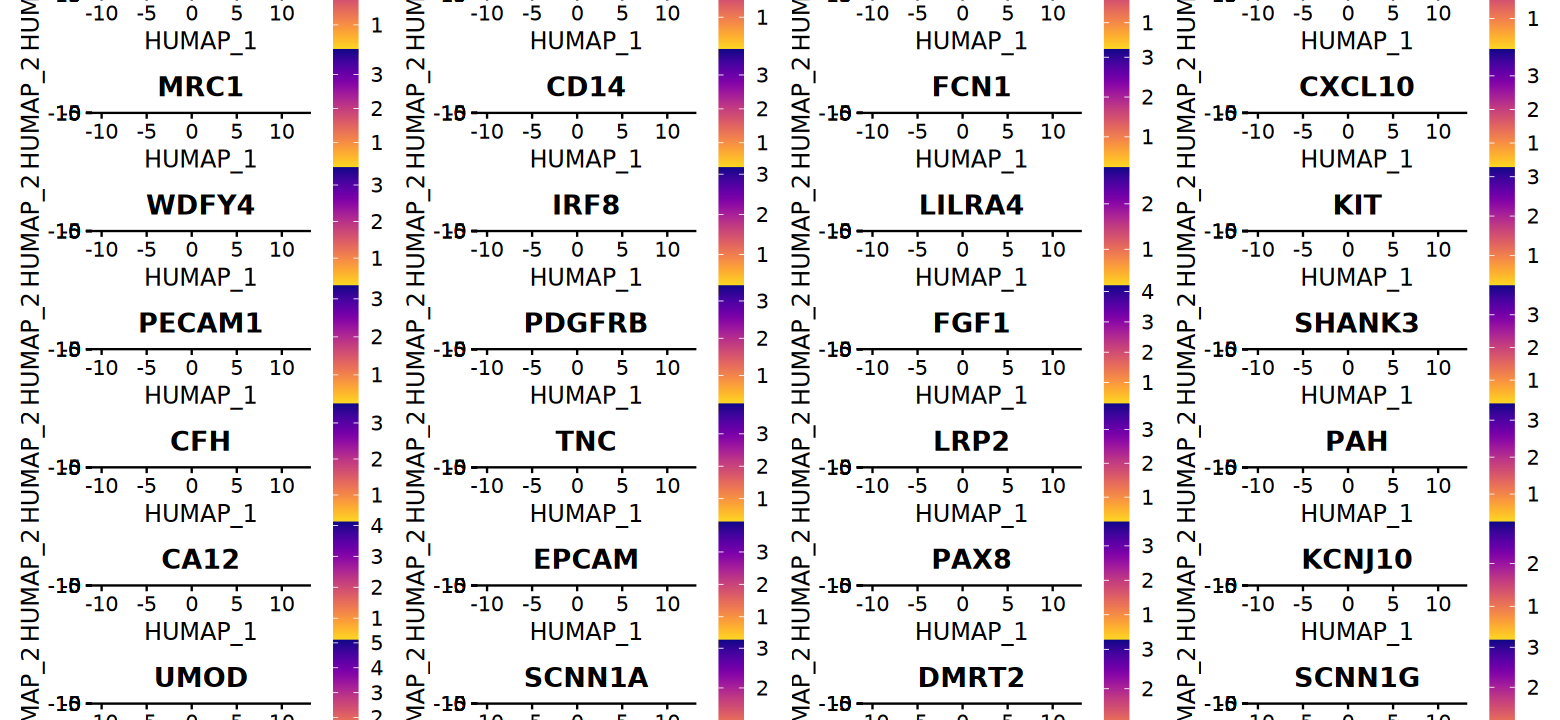

In [103]:
suppfig1e

In [104]:
ggsave("SuppFig2.pdf", width=24, height=32)

In [105]:
getwd()

[1] "/n/data1/bwh/medicine/korsunsky/lab/alvin/ICI/phaseP_JITC"

In [106]:
drug1.res.m2.test = res %>% select(parameter, lennard_label, c_lower, c_effect, c_upper, c_FDR) %>% filter(parameter=='conditionCase')

In [107]:
head(drug1.res.m2.test)

parameter,lennard_label,c_lower,c_effect,c_upper,c_FDR
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
conditionCase,B Cell,0.1569656,0.6530755,1.0123324,0.0023636364
conditionCase,Collecting Duct,-1.4112273,-1.0897139,-0.7302140,0.0000000000
conditionCase,Distal Convoluted Tubule,-1.3099647,-0.9759735,-0.3979731,0.0001071429
conditionCase,Endothelial Cell,-0.9848165,-0.6450451,-0.3297910,0.0002777778
conditionCase,Immune Cell (LowQ),0.5083751,0.9530149,1.3319770,0.0012500000
conditionCase,Inflammatory Myeloid,0.6101793,0.8820585,1.2686269,0.0000000000


# Assemble figures

In [108]:
subtype_order <- drug1.res.m2.test %>%
  group_by(lennard_label) %>%
  summarise(mean_effect = mean(c_effect, na.rm = TRUE)) %>%
  arrange(mean_effect) %>%
  pull(lennard_label)
drugs.res.m2.test <- drug1.res.m2.test %>%
  mutate(lennard_label = factor(lennard_label, levels = subtype_order))

In [109]:
p1 <- ggplot(
  drugs.res.m2.test,
  aes(
    x = lennard_label,
    y = c_effect,
  )
) +
  geom_errorbar(
    aes(ymin = c_lower, ymax = c_upper, alpha = c_FDR < 0.05, linetype = c_FDR > 0.05),
    position = position_dodge(width = 0.6),
    width = 0.25,
    linewidth = 0.9
  ) +
  geom_point(
    aes(alpha = c_FDR < 0.05),
    position = position_dodge(width = 0.6),
    size = 2.5
  ) +
  geom_hline(yintercept = 0, linetype = "dashed") +
  scale_alpha_manual(values = c(0.3, 1), guide = "none") +
  theme_minimal(base_size = 9) +
  theme(
    panel.grid.major.x = element_blank(),
    panel.grid.minor = element_blank(),
  ) +
  labs(
    y = "Effect size",
    x = NULL,
  )+get_theme(size=20, angle=90)+ggsci::scale_color_aaas()

In [110]:
p1comp = p1 | p10 | p20 | p.new  #+ plot_layout(ncol=4, widths = c(1.3, 1.3, 2.5, 2.5)))

In [111]:
p3comp = ((p4b | p4e) / p4c) | (p3T) 

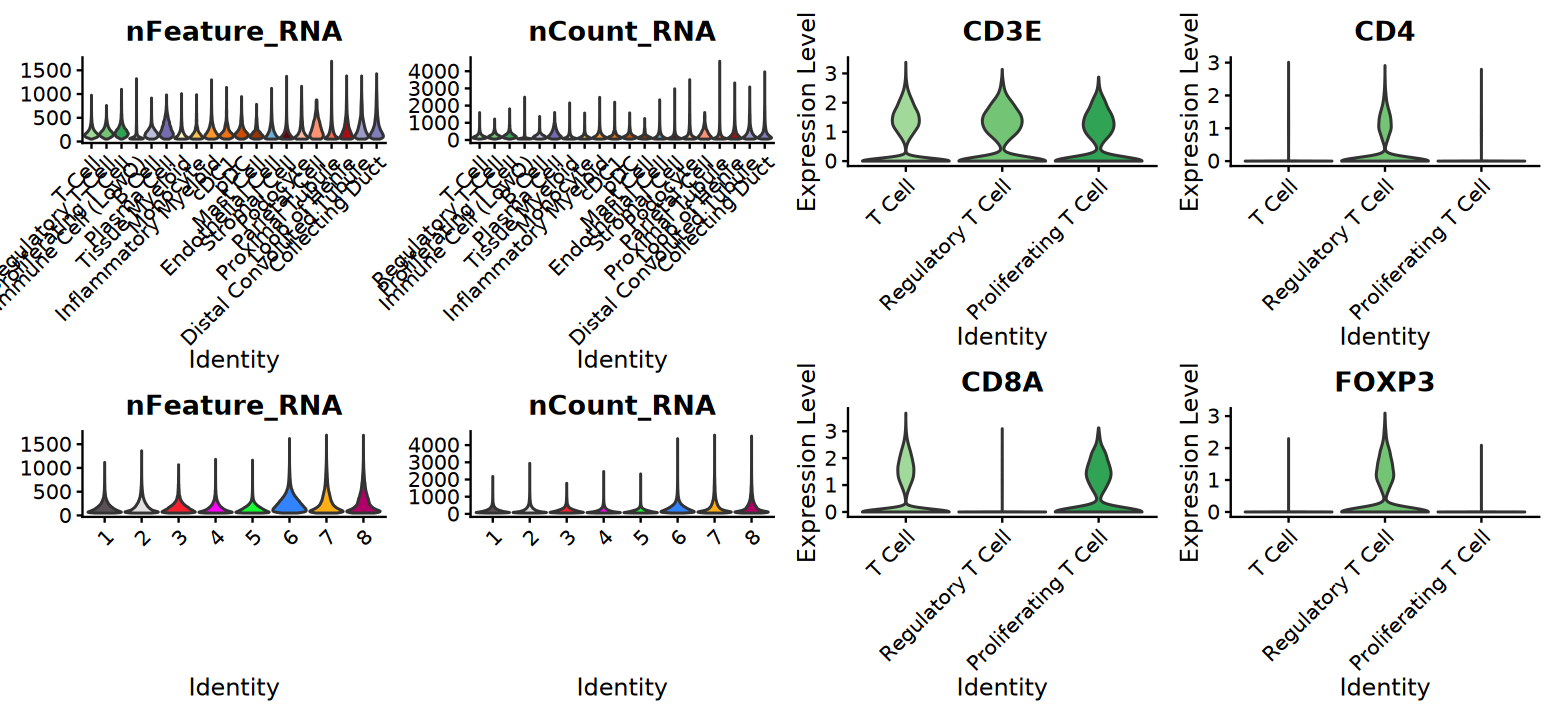

In [112]:
p3comp

In [113]:
p2comp = p11 + p12 # + plot_layout(ncol=2, widths = c(2.5, 2.5)))

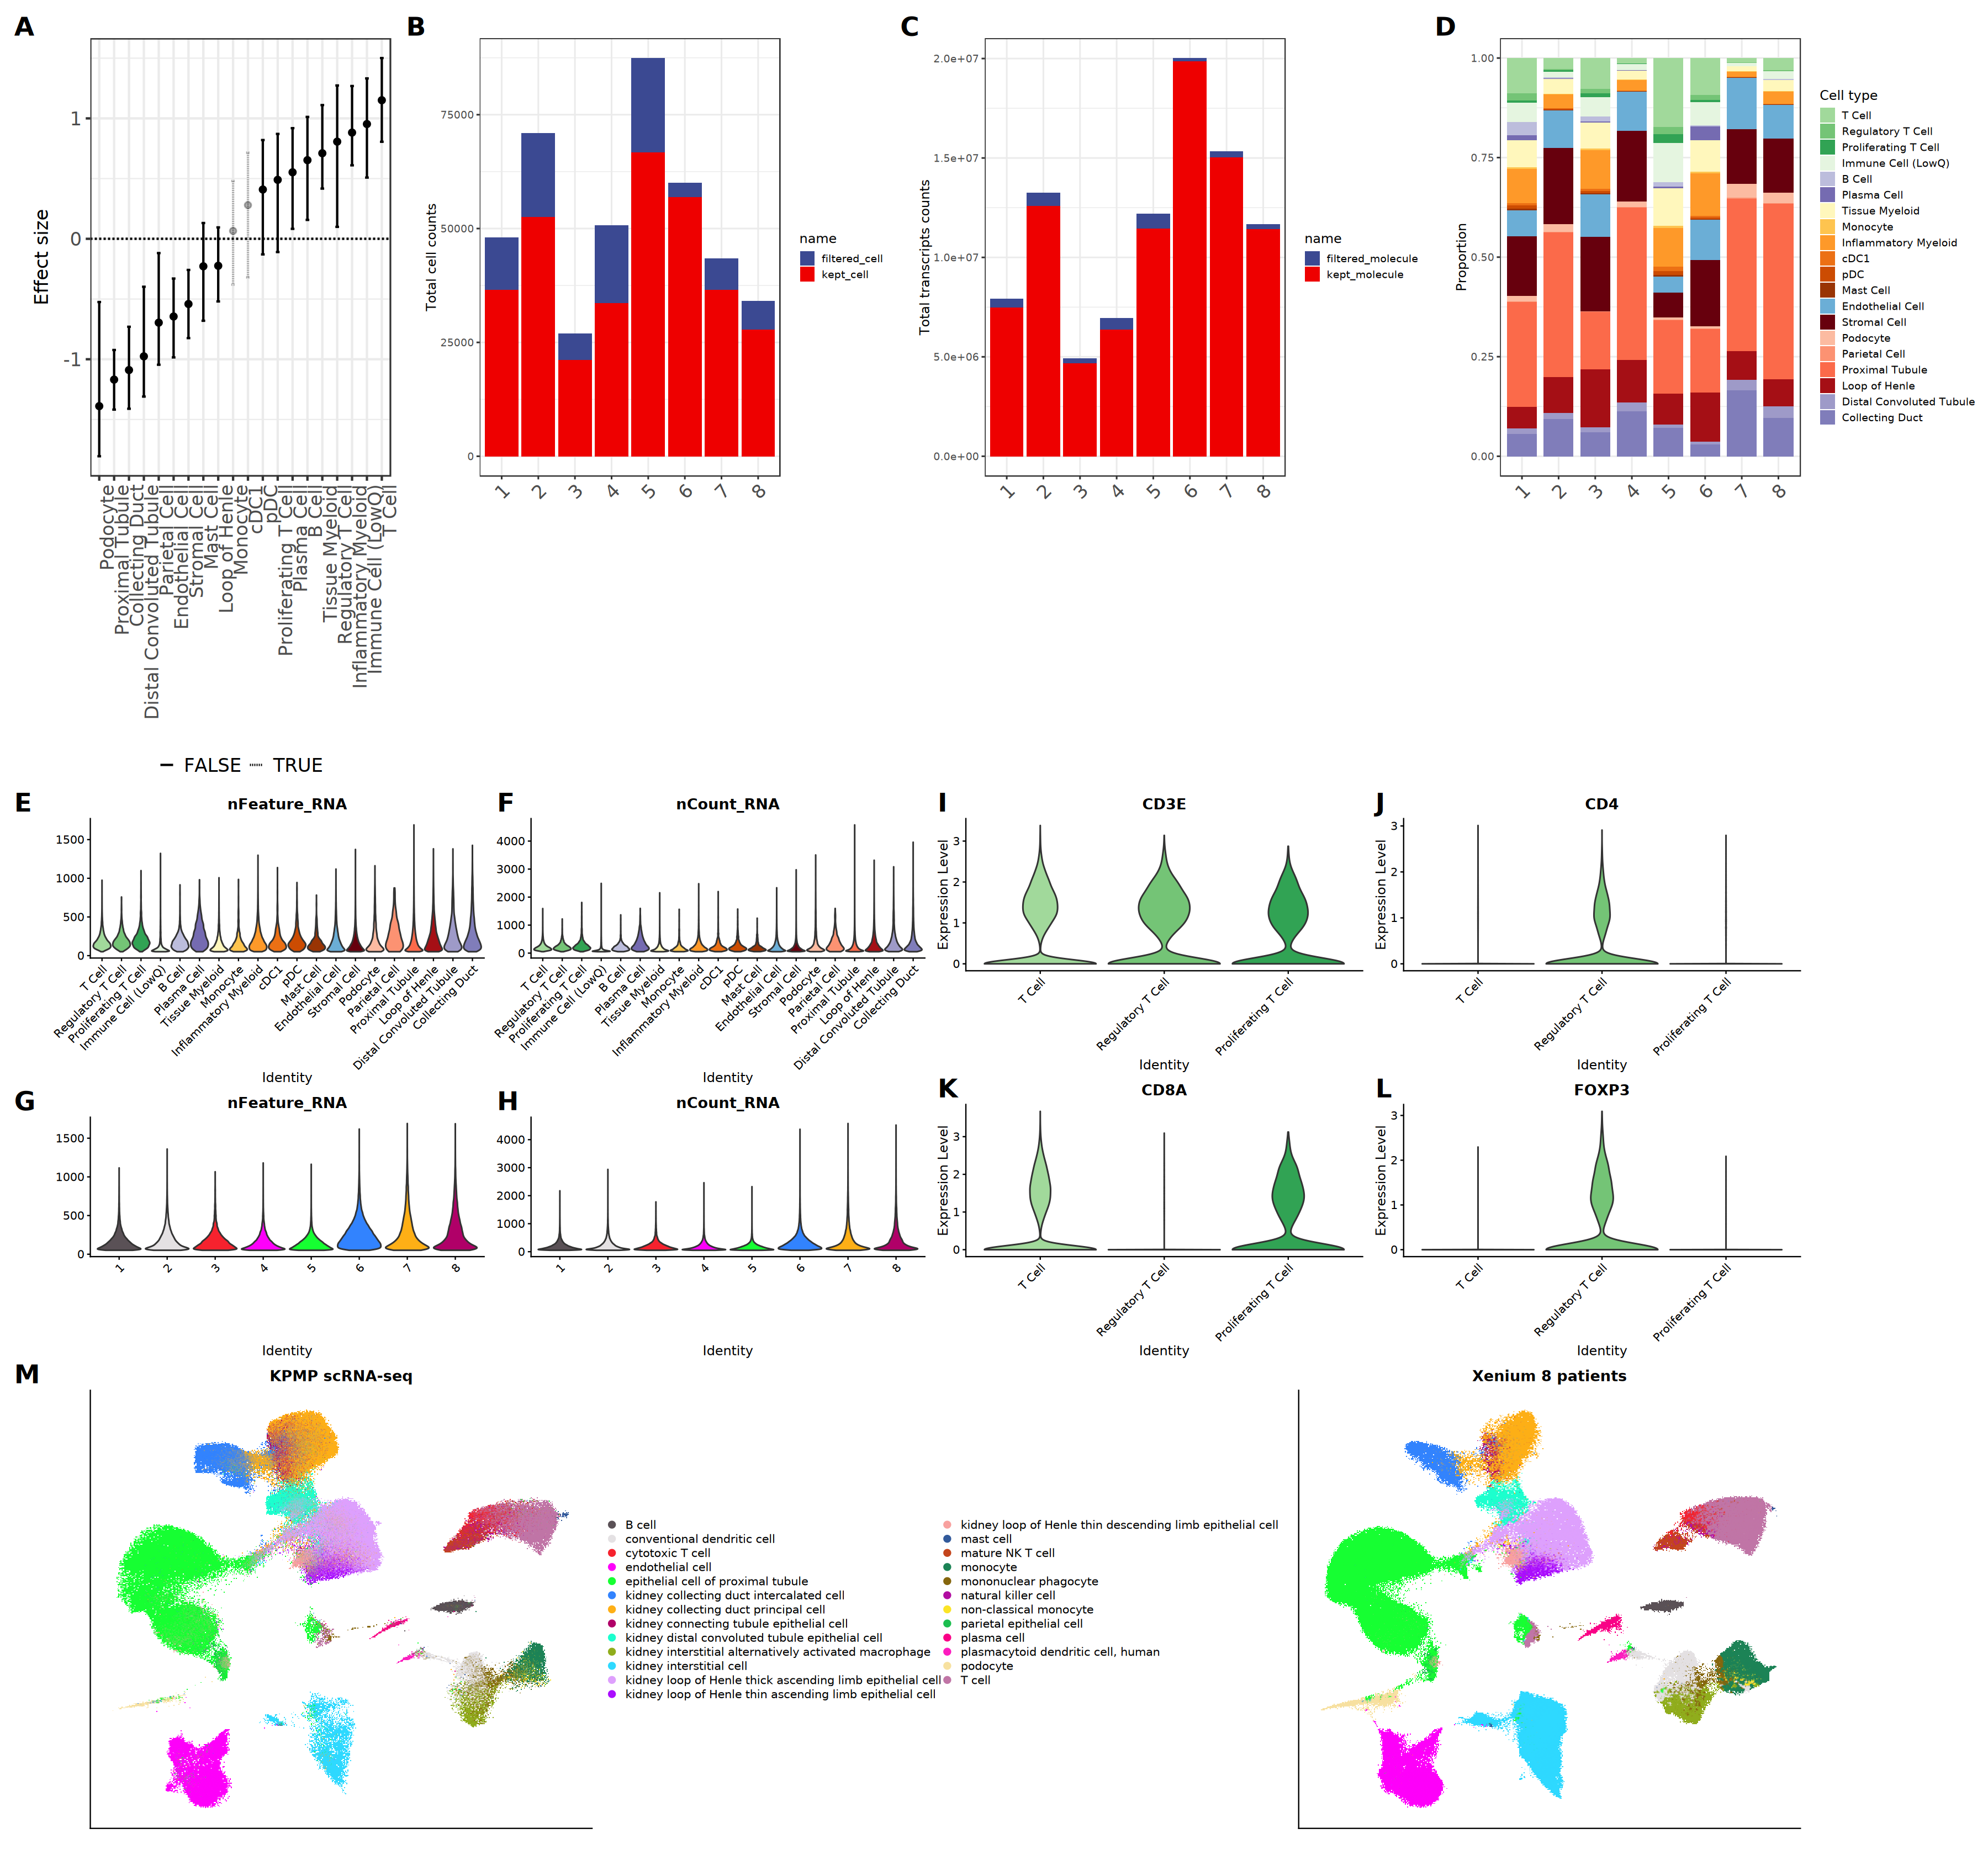

In [114]:
library(patchwork)
fig.size(28, 30)
(((p1comp) / (p3comp) / (p2comp))) + 
 plot_annotation(
    tag_levels = list(c("A", "B", "C", "D", "E", "F", "G", "H", "I", "J", "K", "L", "M")), 
 ) &  theme(plot.tag = element_text(face = "bold", size = 28))

In [115]:
ggsave("SuppFig1.pdf", width=33, height=26)

In [116]:
getwd()

[1] "/n/data1/bwh/medicine/korsunsky/lab/alvin/ICI/phaseP_JITC"